# Clasificador paisajes
Para este ejercicio vas a crear un clasificador automático de paisajes. Los datos los encontrarás en el Classroom como `seg_train.zip` y `seg_test.zip`. Se pide:
1. Cargar las imágenes. Mira cómo están almacenados los datos. Tendrás que recorrer las carpetas, cargar las imágenes en memoria y etiquetarlas con los nombres de las carpetas. Realiza un reshape de cada imagen (comienza el ejercicio con 32x32, para ir más rápido en las ejecuciones).
2. Investiga las imágenes, comprueba con algunas muestras que has cargado bien los datos.
3. Normaliza
4. Diseña la arquitectura de la red. Recuerda que es un algoritmo de clasificación. Ojo con las dimensiones de la entrada
5. Reserva un 20% de los datos del entrenamiento para validar.
6. Representa el objeto history
7. Evalua el modelo con los datos de test
8. Representa algunos de los paisajes donde el modelo comete errores
9. Crea una matriz de confusión con los errores del modelo

**NOTA apartado 1**: para el apartado 1 tendras que recorre las carpetas/imagenes con `os.listdir()`, e ir cargando todas las imagenes como arrays de numpy

**NOTA apartado 4**: empieza con un par de capas Conv2D + MaxPooling2D con activación relu y después la fully connected layer. on softmax como ultima capa

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from skimage.io import imread
import matplotlib.pyplot as plt
import random
import os

In [2]:
# Cargar las imágenes
IMAGE_WIDTH=32
IMAGE_HEIGHT=32
IMAGE_CHANNELS=3
IMAGE_SIZE=(IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS)
BATCH_SIZE = 32
EPOCHS = 30

ROOT_PATH = '/Users/fgoiri/Documents/Documentos_Fatima/clasificador_paisajes/'

TRAIN_PATH = ROOT_PATH+ 'seg_train/'
TEST_PATH = ROOT_PATH + 'seg_test/'


CATEGORIES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

In [3]:
category_to_id = {cat: i for i, cat in enumerate(CATEGORIES)}

# Lista donde guardaremos los registros
data = []

for category in CATEGORIES:
    folder_path = os.path.join(TRAIN_PATH, category)
    
    for file in os.listdir(folder_path):
        if file.lower().endswith(('.jpg', '.png', '.jpeg')):
            
            new_filename = f'{category}/{file}'
            
            data.append({
                'filename': new_filename,
                'category': category_to_id[category]
            })

# Convertimos a DataFrame
df = pd.DataFrame(data)

df.head()

,filename,category
0,buildings/12536.jpg,0
1,buildings/16750.jpg,0
2,buildings/16988.jpg,0
3,buildings/4571.jpg,0
4,buildings/12244.jpg,0


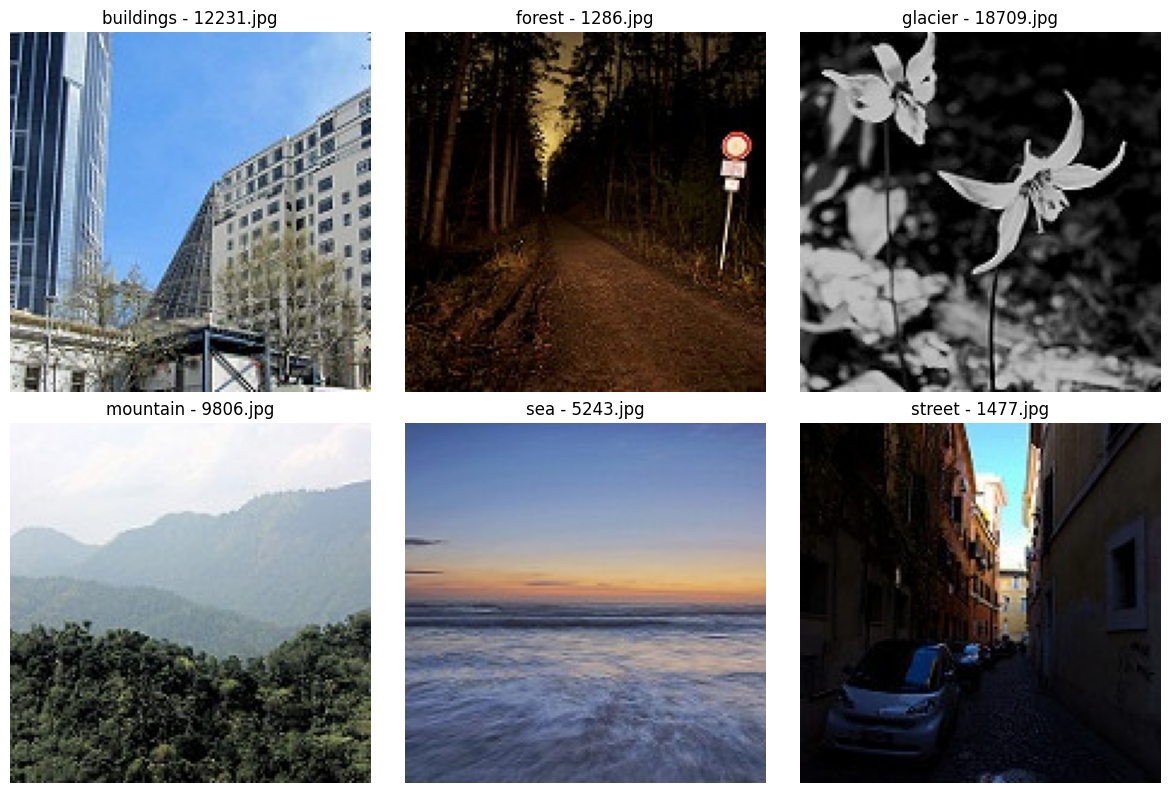

In [4]:
# 2. Investiga las imágenes, comprueba con algunas muestras que has cargado bien los datos.
plt.figure(figsize=(12, 8))

for i, category in enumerate(CATEGORIES):
    
    folder_path = os.path.join(TRAIN_PATH, category)
    
    filenames = [f for f in os.listdir(folder_path)]
    
    sample = random.choice(filenames)
    
    image = imread(os.path.join(folder_path, sample))
    
    # Visualización
    plt.subplot(2, 3, i+1)
    plt.imshow(image)
    plt.title(f"{category} - {sample}")
    plt.axis("off")

plt.tight_layout()
plt.show()

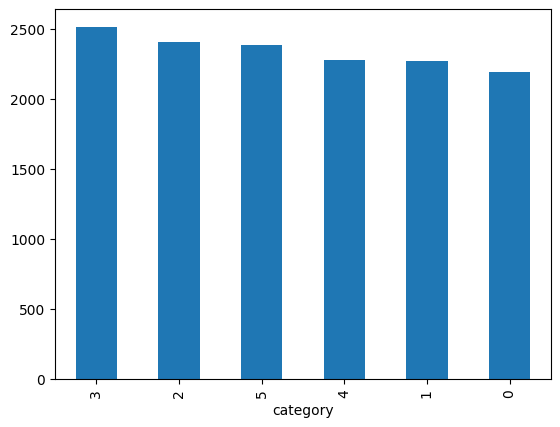

In [5]:
df['category'].value_counts().plot.bar();

In [6]:
# Función para cargar imágenes
import cv2

def read_data(ruta, df, im_size):
    X = []
    Y = []
    
    for c, cat in enumerate(CATEGORIES):
        path = ruta + cat + '/'
    
        ##### CODE #####
        # Iterar sobre todo lo que haya en path
        for file in os.listdir(path):
            
            # Leer la imagen a color y aplicarle el resize
            image = imread(path + file)
            smallimage = cv2.resize(image, (im_size, im_size))
            
            # Guardo en X
            X.append(smallimage)
            Y.append(c)

    return np.array(X), np.array(Y)

In [7]:
X_train, y_train = read_data(TRAIN_PATH, df, IMAGE_WIDTH)
X_test, y_test = read_data(TEST_PATH, df, IMAGE_WIDTH)

print(X_train.shape)
print(X_test.shape)

(14034, 32, 32, 3)
(3000, 32, 32, 3)


In [8]:
# 3. Normaliza
# Buscamos max y min para normalizar
print("Min:", np.min(X_train))
print("Max:", np.max(X_train))

Min: 0
Max: 255


In [9]:
# Dividimos entre el max
X_train = X_train / 255.0
X_test = X_test / 255.0
# Comprobamos que este bien
print("Min:", np.min(X_train))
print("Max:", np.max(X_train))

Min: 0.0
Max: 1.0


In [10]:
# 4. Diseña la arquitectura de la red. Recuerda que es un algoritmo de clasificación. Ojo con las dimensiones de la entrada
from tensorflow import keras
layers = [
    keras.layers.Conv2D(64, (3,3), activation='relu', input_shape=IMAGE_SIZE),
    keras.layers.MaxPooling2D(pool_size=(2,2)),
    
    keras.layers.Conv2D(128, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2,2)),
    
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(6, activation='softmax')
]

model = keras.Sequential(layers)

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

/Users/fgoiri/miniconda3/envs/bootcamp2/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 674,246 (2.57 MB)

 Trainable params: 674,246 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# 5. Reserva un 20% de los datos del entrenamiento para validar.
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint

earlystop = EarlyStopping(patience=10)
mcheckpoint = ModelCheckpoint("callback_model.keras")

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=128,
    callbacks=[earlystop, mcheckpoint],
    validation_data=(X_val, y_val)
)

Epoch 1/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.5303 - loss: 1.1801 - val_accuracy: 0.6459 - val_loss: 0.9181
Epoch 2/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.6611 - loss: 0.8892 - val_accuracy: 0.6943 - val_loss: 0.8088
Epoch 3/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.6960 - loss: 0.8207 - val_accuracy: 0.6687 - val_loss: 0.8925
Epoch 4/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.7349 - loss: 0.7238 - val_accuracy: 0.7463 - val_loss: 0.7028
Epoch 5/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.7614 - loss: 0.6572 - val_accuracy: 0.7310 - val_loss: 0.7047
Epoch 6/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.7863 - loss: 0.5988 - val_accuracy: 0.7659 - val_loss: 0.6334
Epoch 7/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.7982 - loss: 0.5663 - val_accuracy: 0.7738 - val_loss: 0.6253
Epoch 8/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.8101 - loss: 0.5269 - val_accuracy: 0.7520 - v

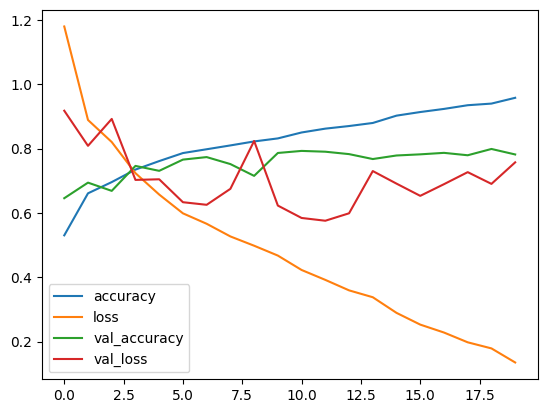

In [14]:
# 6. Representa el objeto history
pd.DataFrame(history.history).plot();

In [ ]:
# 7. Evalua el modelo con los datos de test
loss, acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\nTest accuracy: {acc:.4f}")
# buenoooooo....

94/94 - 0s - 4ms/step - accuracy: 0.7757 - loss: 0.8194

Test accuracy: 0.7757


94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


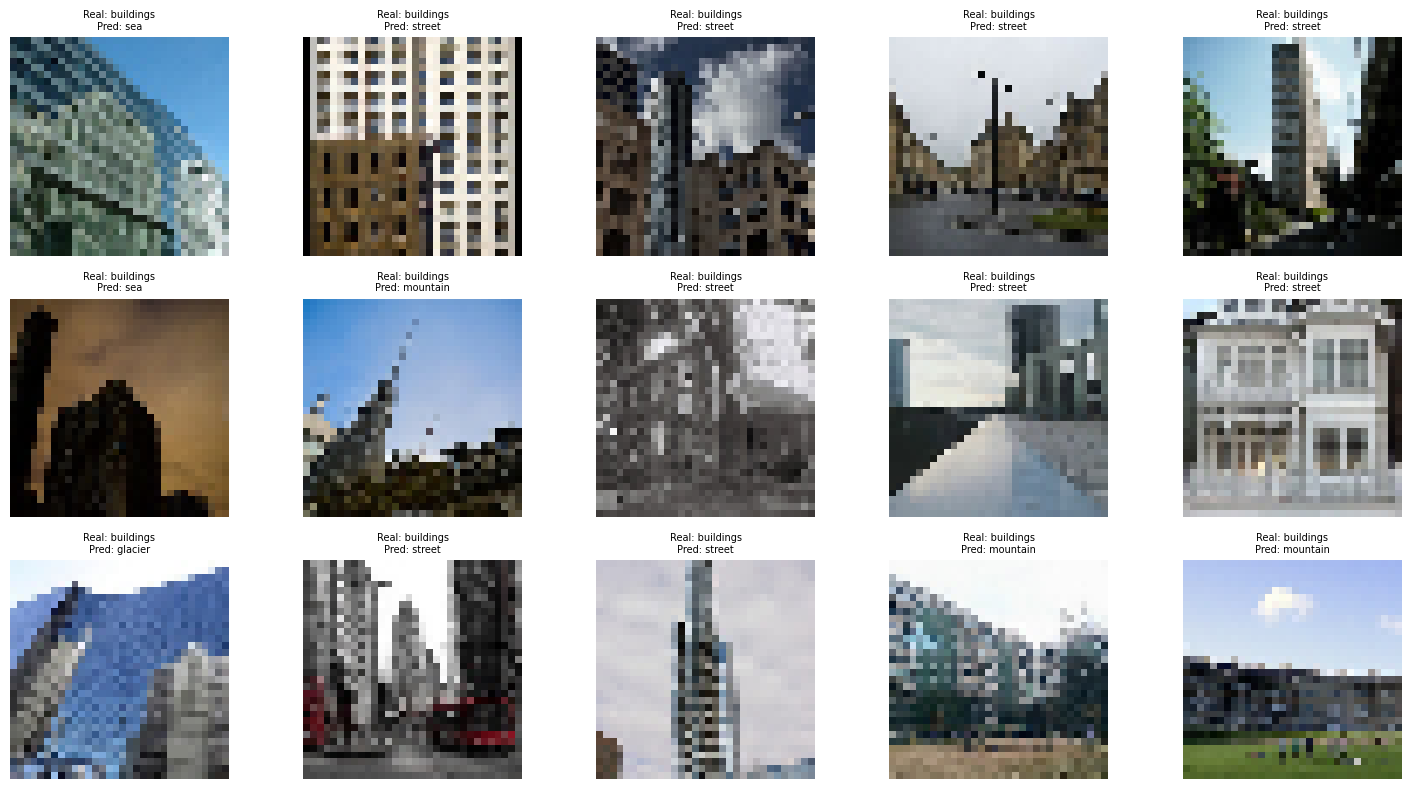

In [ ]:
# 8. Representa algunos de los paisajes donde el modelo comete errores
y_pred = np.argmax(model.predict(X_test), axis=1)

# Índices donde falla
error_idx = np.where(y_pred != y_test)[0]

plt.figure(figsize=(15, 8))
for i, idx in enumerate(error_idx[:15]):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_test[idx])
    plt.title(f"Real: {CATEGORIES[y_test[idx]]}\nPred: {CATEGORIES[y_pred[idx]]}", fontsize=7)
    plt.axis('off')

plt.tight_layout();
# Cosas peores se han visto como confundir un edificio con el mar jajajajajaj

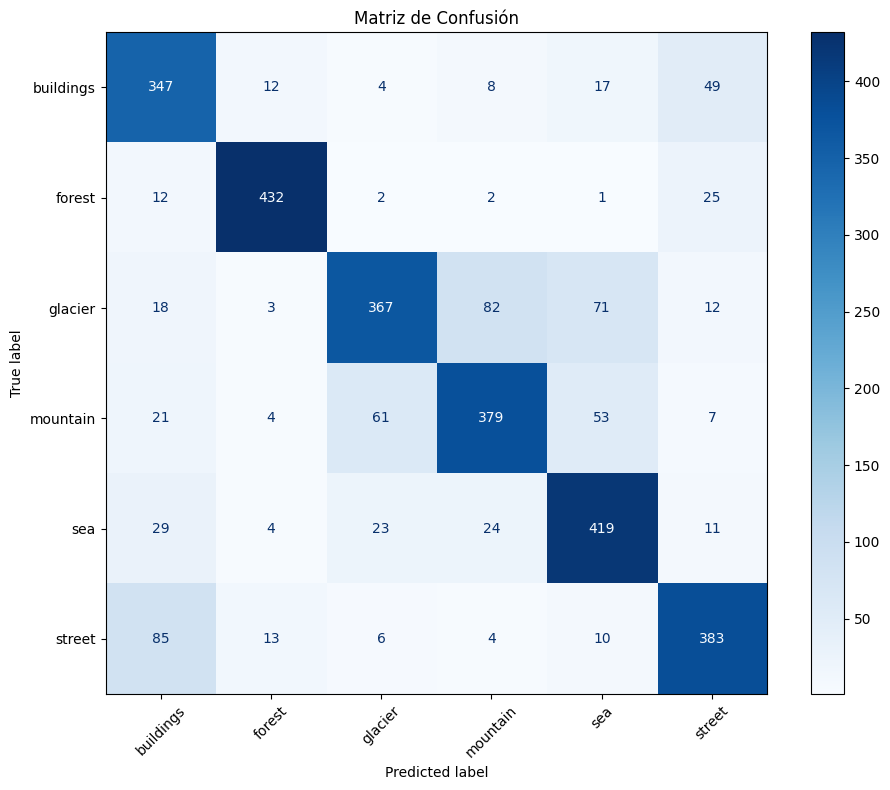

In [17]:
# 9. Crea una matriz de confusión con los errores del modelo
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CATEGORIES)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, cmap='Blues')
plt.title('Matriz de Confusión')
plt.tight_layout();